In [1]:
# %%
import math
from dataclasses import dataclass
from contextlib import ExitStack

import torch
import gpytorch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7.5, 4.5)
plt.rcParams["figure.dpi"] = 120

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [2]:
# %%
def f0(x: torch.Tensor) -> torch.Tensor:
    """True latent f (noiseless)."""
    return torch.sin(2 * math.pi * x) + 0.5 * torch.cos(3 * x)


def make_stratified_points_1d(n, low, high, generator, device, dtype):
    """1D stratified (LHS-like) points on [low, high]."""
    i = torch.arange(n, device=device, dtype=dtype)
    u = (i + torch.rand(n, generator=generator, device=device, dtype=dtype)) / n
    x = low + (high - low) * u
    perm = torch.randperm(n, generator=generator, device=device)
    return x[perm].unsqueeze(-1)


class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points_std: torch.Tensor):
        M = inducing_points_std.size(0)
        q_dist = gpytorch.variational.CholeskyVariationalDistribution(M)
        q_strat = gpytorch.variational.VariationalStrategy(
            self, inducing_points_std, q_dist, learn_inducing_locations=False
        )
        super().__init__(q_strat)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x_std):
        mean_x = self.mean_module(x_std)
        covar_x = self.covar_module(x_std)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def clone_state_dict(sd):
    out = {}
    for k, v in sd.items():
        out[k] = v.detach().clone() if torch.is_tensor(v) else v
    return out


In [3]:
# %%
def freeze_all_params(model, likelihood):
    for p in model.parameters():
        p.requires_grad_(False)
    for p in likelihood.parameters():
        p.requires_grad_(False)


def pick_covariance_params_svgp(model):
    """Select variational covariance parameters only (for Stage-2)."""
    trainables, names = [], []
    vdist_mod = None
    vs = getattr(model, "variational_strategy", None)
    if vs is not None:
        if hasattr(vs, "_variational_distribution"):
            vdist_mod = getattr(vs, "_variational_distribution")
        else:
            cand = getattr(vs, "variational_distribution", None)
            if isinstance(cand, torch.nn.Module):
                vdist_mod = cand
    if isinstance(vdist_mod, torch.nn.Module):
        for n, p in vdist_mod.named_parameters(recurse=True):
            low = n.lower()
            if "mean" in low:
                p.requires_grad_(False)
            elif any(k in low for k in ["chol", "std", "var", "covar", "factor"]):
                p.requires_grad_(True)
                trainables.append(p)
                names.append(f"vdist.{n}")
            else:
                p.requires_grad_(False)
    if not trainables:
        allow = (
            "chol_variational_covar", "variational_distribution.chol_covar",
            "variational_distribution._cholesky_factor", "_variational_distribution.chol_covar",
            "raw_covar", "chol_factor", "covar_factor", "variational_stddev", "raw_var",
            "qchol", "q_scale_tril"
        )
        for n, p in model.named_parameters():
            low = n.lower()
            if "variational_strategy" in low and any(k in low for k in allow) and "mean" not in low:
                p.requires_grad_(True)
                trainables.append(p)
                names.append(n)
    return trainables, names


def stage1_train(
    model,
    likelihood,
    x_train_std,
    y_train,
    lr=2e-2,
    epochs=2000,
    jitter=1e-2,
    batch_size=500,
    early_stop_patience=60,
    early_stop_min_delta=1e-4,
):
    N = x_train_std.size(0)
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=1.0)

    likelihood.noise_covar.raw_noise.requires_grad_(False)
    opt = torch.optim.Adam(
        [
            {"params": model.variational_parameters()},
            {"params": model.hyperparameters()},
            {"params": likelihood.parameters()},
        ],
        lr=lr,
    )

    loader = DataLoader(
        TensorDataset(x_train_std, y_train),
        batch_size=batch_size,
        shuffle=True,
    )

    model.train()
    likelihood.train()

    neg_elbo_hist = []
    best_loss = float("inf")
    best_epoch = 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd = clone_state_dict(likelihood.state_dict())
    patience = 0

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1:
                    loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                total += float(loss.item())
                n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)

            if best_loss - avg_loss > early_stop_min_delta:
                best_loss = avg_loss
                best_epoch = ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd = clone_state_dict(likelihood.state_dict())
                patience = 0
            else:
                patience += 1

            if patience >= early_stop_patience:
                break

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval()
    likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss


def stage2_train_cov_only(
    model,
    likelihood,
    x_train_std,
    y_train,
    beta,
    lr=2e-2,
    epochs=800,
    jitter=1e-2,
    batch_size=500,
):
    N = x_train_std.size(0)
    freeze_all_params(model, likelihood)
    cov_params, cov_names = pick_covariance_params_svgp(model)
    assert cov_params, "No covariance params found to train in Stage-2."

    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=beta)
    opt = torch.optim.Adam(cov_params, lr=lr)

    loader = DataLoader(
        TensorDataset(x_train_std, y_train),
        batch_size=batch_size,
        shuffle=True,
    )

    model.train()
    likelihood.train()
    neg_elbo_hist = []
    best_loss = float("inf")
    best_epoch = 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd = clone_state_dict(likelihood.state_dict())

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1:
                    loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(cov_params, 5.0)
                opt.step()
                total += float(loss.item())
                n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)
            if avg_loss < best_loss:
                best_loss = avg_loss
                best_epoch = ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd = clone_state_dict(likelihood.state_dict())

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval()
    likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss, cov_names


In [4]:
# %%
@dataclass
class CFG:
    n_train: int = 500
    n_test: int = 50
    train_low: float = -2.5
    train_high: float = 2.5
    test_low: float = -2.5
    test_high: float = 2.5
    inducing_points: int = 50
    use_fp64: bool = True
    jitter: float = 1e-2
    stage1_epochs: int = 2000
    stage2_epochs: int = 800
    batch_size: int = 500
    lr_adam_stage1: float = 2e-2
    lr_adam_stage2: float = 2e-2
    seed: int = 13

cfg = CFG()
torch.set_default_dtype(torch.float64 if cfg.use_fp64 else torch.float32)

# 只做 1 个 replication
rep_id = 0
seed = cfg.seed + rep_id
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

gen = torch.Generator(device=device).manual_seed(seed)

# 训练 / 测试
x_train_raw = make_stratified_points_1d(
    n=cfg.n_train,
    low=cfg.train_low,
    high=cfg.train_high,
    generator=gen,
    device=device,
    dtype=torch.get_default_dtype(),
)
x_test_raw = torch.linspace(
    cfg.test_low, cfg.test_high, cfg.n_test,
    device=device, dtype=torch.get_default_dtype()
).unsqueeze(1)

y_train_full = f0(x_train_raw).squeeze(-1)
y_test_true = f0(x_test_raw).squeeze(-1)

# 对称标准化
mid = torch.tensor([(cfg.train_low + cfg.train_high) / 2.0],
                   device=device, dtype=torch.get_default_dtype())
half = torch.tensor([(cfg.train_high - cfg.train_low) / 2.0],
                    device=device, dtype=torch.get_default_dtype()).clamp_min(1e-12)

def to_std(x_raw):
    return (x_raw - mid) / half

x_train_std_full = to_std(x_train_raw)
x_test_std = to_std(x_test_raw)

# 固定 Z
Z_raw = torch.linspace(
    cfg.train_low, cfg.train_high, cfg.inducing_points,
    device=device, dtype=torch.get_default_dtype()
).unsqueeze(1)
Z_std = to_std(Z_raw)

# 两切
n_train = cfg.n_train
perm = torch.randperm(n_train, device=device)
half_n = n_train // 2
split1_idx = perm[:half_n]
split2_idx = perm[half_n:]

x_s1_std = x_train_std_full[split1_idx]
y_s1 = y_train_full[split1_idx]
x_s2_std = x_train_std_full[split2_idx]
y_s2 = y_train_full[split2_idx]

print("x_train_raw shape:", x_train_raw.shape)
print("x_s1_std shape:", x_s1_std.shape, "x_s2_std shape:", x_s2_std.shape)


x_train_raw shape: torch.Size([500, 1])
x_s1_std shape: torch.Size([250, 1]) x_s2_std shape: torch.Size([250, 1])


Split1 Stage-1 best -ELBO=-1.5510 @ epoch 1000
Split2 Stage-1 best -ELBO=-1.4385 @ epoch 621


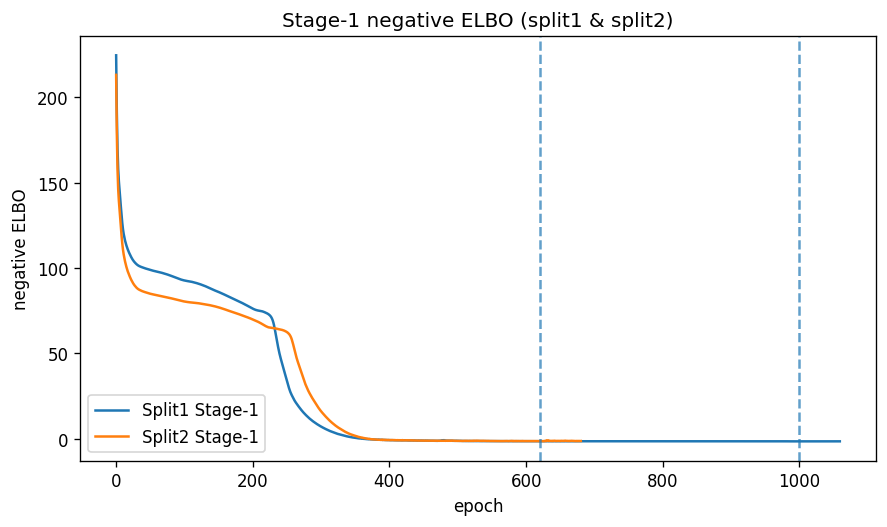

In [5]:
# %%
# Stage-1 on split1 -> pseudo-truth
model_s1 = SVGPModel(Z_std.clone().contiguous()).to(device)
lik_s1 = gpytorch.likelihoods.GaussianLikelihood().to(device)
with torch.no_grad():
    model_s1.covar_module.base_kernel.lengthscale.fill_(1.0)
    model_s1.covar_module.outputscale.fill_(1.0)
    lik_s1.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)

hist_s1, best_ep_s1, best_loss_s1 = stage1_train(
    model_s1, lik_s1,
    x_s1_std, y_s1,
    lr=cfg.lr_adam_stage1,
    epochs=cfg.stage1_epochs,
    jitter=cfg.jitter,
    batch_size=cfg.batch_size,
)

print(f"Split1 Stage-1 best -ELBO={best_loss_s1:.4f} @ epoch {best_ep_s1}")

# Stage-1 on split2 (base for calibration)
model_s2 = SVGPModel(Z_std.clone().contiguous()).to(device)
lik_s2 = gpytorch.likelihoods.GaussianLikelihood().to(device)
with torch.no_grad():
    model_s2.covar_module.base_kernel.lengthscale.fill_(1.0)
    model_s2.covar_module.outputscale.fill_(1.0)
    lik_s2.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)

hist_s2_base, best_ep_s2_base, best_loss_s2_base = stage1_train(
    model_s2, lik_s2,
    x_s2_std, y_s2,
    lr=cfg.lr_adam_stage1,
    epochs=cfg.stage1_epochs,
    jitter=cfg.jitter,
    batch_size=cfg.batch_size,
)

print(f"Split2 Stage-1 best -ELBO={best_loss_s2_base:.4f} @ epoch {best_ep_s2_base}")

# Plot Stage-1 negative ELBO curves
plt.figure()
plt.plot(hist_s1, label="Split1 Stage-1")
plt.axvline(best_ep_s1-1, linestyle="--", alpha=0.7)
plt.plot(hist_s2_base, label="Split2 Stage-1")
plt.axvline(best_ep_s2_base-1, linestyle="--", alpha=0.7)
plt.xlabel("epoch")
plt.ylabel("negative ELBO")
plt.title("Stage-1 negative ELBO (split1 & split2)")
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
# %%
# pseudo-truth from split1 Stage-1
with torch.no_grad():
    pred_truth = model_s1(x_test_std)
    mu_truth = pred_truth.mean

# split2 Stage-1 mean
with torch.no_grad():
    pred_s2_base = model_s2(x_test_std)
    mu_s2_base = pred_s2_base.mean

# Stage-2 for alpha in {1.0, 0.5} on split2 (single bootstrap = identity)
alphas_to_plot = [1.0, 0.5]
stage2_means = {}
stage2_lower = {}
stage2_upper = {}

for alpha in alphas_to_plot:
    beta = 1.0 / alpha

    # reset to Stage-1 base
    model_tmp = SVGPModel(Z_std.clone().contiguous()).to(device)
    lik_tmp = gpytorch.likelihoods.GaussianLikelihood().to(device)
    model_tmp.load_state_dict(model_s2.state_dict())
    lik_tmp.load_state_dict(lik_s2.state_dict())

    hist_s2, best_ep_s2, best_loss_s2, _ = stage2_train_cov_only(
        model_tmp, lik_tmp,
        x_s2_std, y_s2,
        beta=beta,
        lr=cfg.lr_adam_stage2,
        epochs=cfg.stage2_epochs,
        jitter=cfg.jitter,
        batch_size=cfg.batch_size,
    )
    print(f"Stage-2 alpha={alpha:.2f}, best -ELBO={best_loss_s2:.4f} @ epoch {best_ep_s2}")

    # 保存一个 Stage-2 的 ELBO 曲线（alpha=1.0）方便画图
    if alpha == 1.0:
        hist_s2_alpha1 = hist_s2

    with torch.no_grad():
        pred = model_tmp(x_test_std)
        mu = pred.mean
        std = pred.variance.sqrt().clamp_min(1e-12)
        lower = mu - 1.96 * std
        upper = mu + 1.96 * std

    stage2_means[alpha] = mu.detach().cpu()
    stage2_lower[alpha] = lower.detach().cpu()
    stage2_upper[alpha] = upper.detach().cpu()


Stage-2 alpha=1.00, best -ELBO=-1.4515 @ epoch 659
Stage-2 alpha=0.50, best -ELBO=-1.0123 @ epoch 756


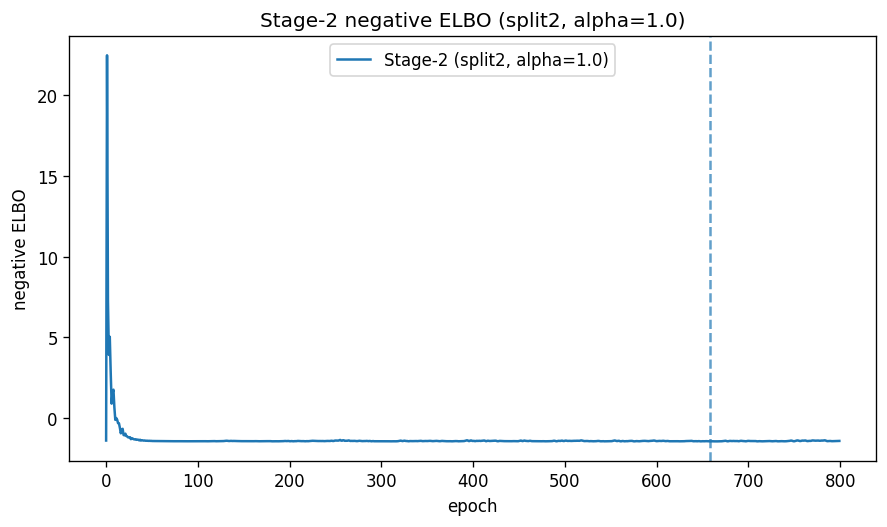

In [7]:
# %%
plt.figure()
plt.plot(hist_s2_alpha1, label="Stage-2 (split2, alpha=1.0)")
plt.axvline(np.argmin(hist_s2_alpha1), linestyle="--", alpha=0.7)
plt.xlabel("epoch")
plt.ylabel("negative ELBO")
plt.title("Stage-2 negative ELBO (split2, alpha=1.0)")
plt.legend()
plt.tight_layout()
plt.show()


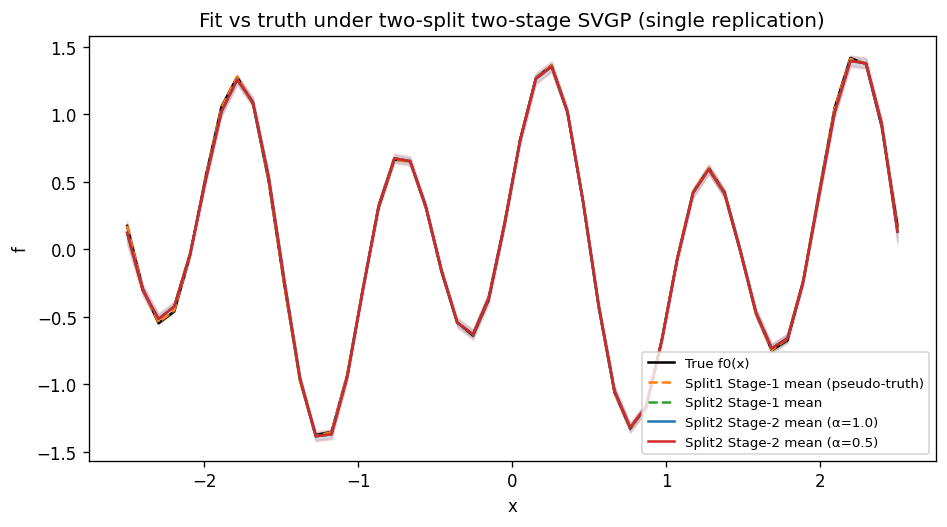

In [8]:
# %%
xs = x_test_raw.squeeze(-1).cpu().numpy()
y_true = y_test_true.cpu().numpy()
mu_truth_np = mu_truth.cpu().numpy()
mu_s2_base_np = mu_s2_base.cpu().numpy()

plt.figure(figsize=(8, 4.5))

# true f0
plt.plot(xs, y_true, "k-", label="True f0(x)")

# pseudo-truth (split1 Stage-1)
plt.plot(xs, mu_truth_np, "C1--", label="Split1 Stage-1 mean (pseudo-truth)")

# split2 Stage-1 mean
plt.plot(xs, mu_s2_base_np, "C2--", label="Split2 Stage-1 mean")

# Stage-2 alpha=1.0
alpha = 1.0
plt.plot(xs, stage2_means[alpha], "C0-", label=f"Split2 Stage-2 mean (α={alpha})")
plt.fill_between(xs, stage2_lower[alpha], stage2_upper[alpha],
                 color="C0", alpha=0.15)

# Stage-2 alpha=0.5
alpha = 0.5
plt.plot(xs, stage2_means[alpha], "C3-", label=f"Split2 Stage-2 mean (α={alpha})")
plt.fill_between(xs, stage2_lower[alpha], stage2_upper[alpha],
                 color="C3", alpha=0.12)

plt.xlabel("x")
plt.ylabel("f")
plt.title("Fit vs truth under two-split two-stage SVGP (single replication)")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


[00:45:13] Using device: cuda
[00:45:13] === Single replication rep_id=0, seed=13 ===
[00:45:13] x_train_raw shape = (500, 1)
[00:45:13] x_test_raw shape = (50, 1)
[00:45:13] Split1 size = 250, Split2 size = 250
[00:45:13] [Stage1_split1] start training, epochs=2000, N=250, batch=500
[00:45:13] [Stage1_split1] epoch 0001  -ELBO=224.587393  (best 224.587393@1)
[00:45:13] [Stage1_split1] epoch 0050  -ELBO=98.956258  (best 98.956258@50)
[00:45:14] [Stage1_split1] epoch 0100  -ELBO=92.774072  (best 92.774072@100)
[00:45:14] [Stage1_split1] epoch 0150  -ELBO=86.096704  (best 86.096704@150)
[00:45:15] [Stage1_split1] epoch 0200  -ELBO=76.402353  (best 76.402353@200)
[00:45:15] [Stage1_split1] epoch 0250  -ELBO=35.179254  (best 35.179254@250)
[00:45:16] [Stage1_split1] epoch 0300  -ELBO=7.309034  (best 7.309034@300)
[00:45:17] [Stage1_split1] epoch 0350  -ELBO=0.585764  (best 0.585764@350)
[00:45:18] [Stage1_split1] epoch 0400  -ELBO=-0.807951  (best -0.807951@400)
[00:45:18] [Stage1_split1] 

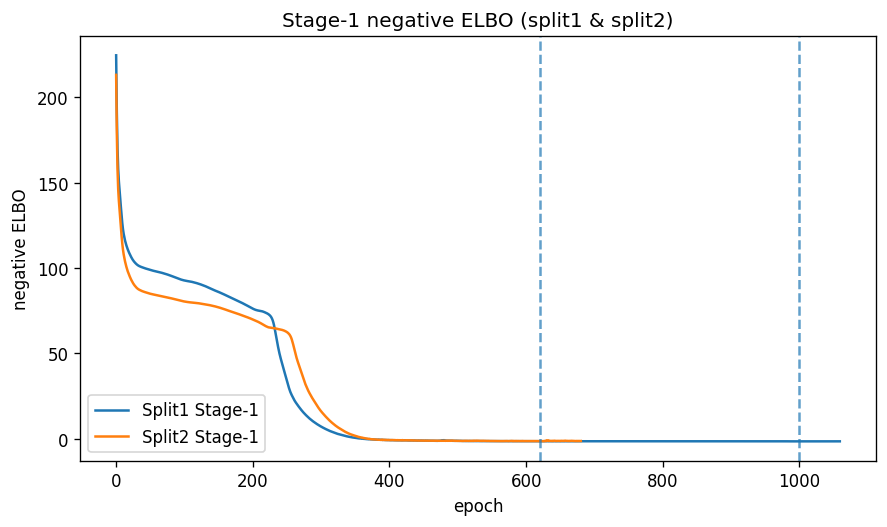

[00:45:35] [Stage2_alpha0.10] start training, beta=10.0000, epochs=800, N=250, batch=500
[00:45:35] [Stage2_alpha0.10] epoch 0001  -ELBO=2.691574  (best 2.691574@1)
[00:45:36] [Stage2_alpha0.10] epoch 0050  -ELBO=2.260848  (best 2.260848@50)
[00:45:36] [Stage2_alpha0.10] epoch 0100  -ELBO=2.208431  (best 2.203148@93)
[00:45:37] [Stage2_alpha0.10] epoch 0150  -ELBO=2.212979  (best 2.201011@107)
[00:45:38] [Stage2_alpha0.10] epoch 0200  -ELBO=2.226096  (best 2.199826@183)
[00:45:38] [Stage2_alpha0.10] epoch 0250  -ELBO=2.266906  (best 2.199826@183)
[00:45:39] [Stage2_alpha0.10] epoch 0300  -ELBO=2.207322  (best 2.199826@183)
[00:45:39] [Stage2_alpha0.10] epoch 0350  -ELBO=2.202086  (best 2.199379@347)
[00:45:40] [Stage2_alpha0.10] epoch 0400  -ELBO=2.238781  (best 2.197914@358)
[00:45:40] [Stage2_alpha0.10] epoch 0450  -ELBO=2.201985  (best 2.197914@358)
[00:45:40] [Stage2_alpha0.10] epoch 0500  -ELBO=2.225068  (best 2.197914@358)
[00:45:41] [Stage2_alpha0.10] epoch 0550  -ELBO=2.227939 

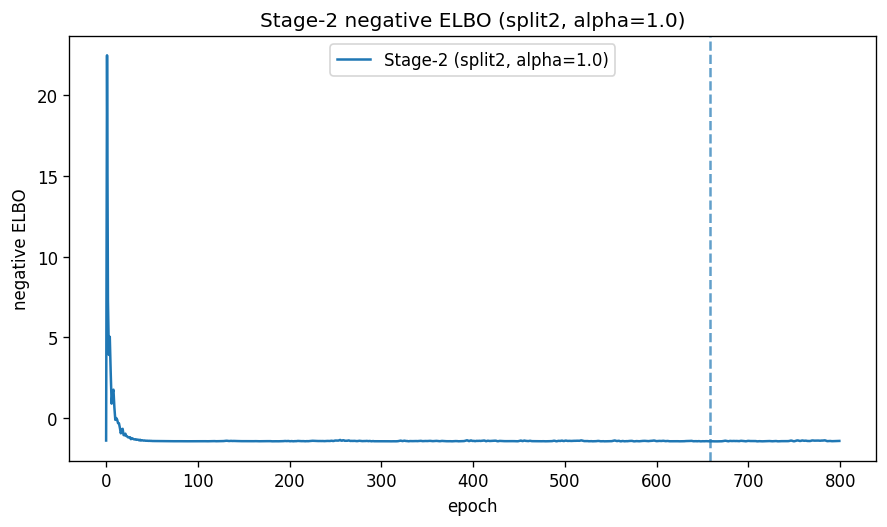

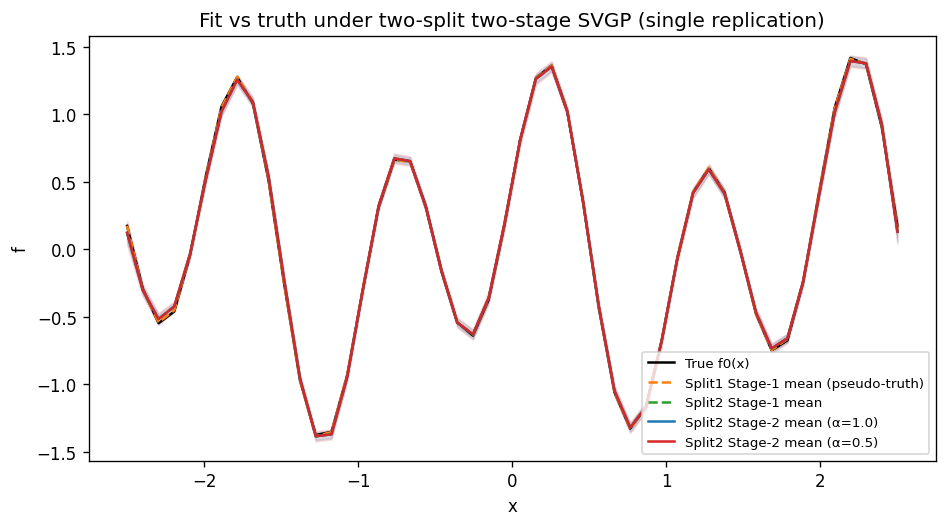

[00:47:07] Done.


In [9]:
import math
import time
from dataclasses import dataclass

import torch
import gpytorch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ---------- logging helpers ----------
def now():
    return time.strftime("%H:%M:%S")

def log(msg):
    print(f"[{now()}] {msg}", flush=True)

# ---------- basic setup ----------
plt.rcParams["figure.figsize"] = (7.5, 4.5)
plt.rcParams["figure.dpi"] = 120

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log(f"Using device: {device}")

# ---------- data-generating process ----------
def f0(x: torch.Tensor) -> torch.Tensor:
    """True latent function (noiseless)."""
    return torch.sin(2 * math.pi * x) + 0.5 * torch.cos(3 * x)

def make_stratified_points_1d(n, low, high, generator, device, dtype):
    """1D stratified (LHS-like) points on [low, high]."""
    i = torch.arange(n, device=device, dtype=dtype)
    u = (i + torch.rand(n, generator=generator, device=device, dtype=dtype)) / n
    x = low + (high - low) * u
    perm = torch.randperm(n, generator=generator, device=device)
    return x[perm].unsqueeze(-1)

# ---------- SVGP model ----------
class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points_std: torch.Tensor):
        M = inducing_points_std.size(0)
        q_dist = gpytorch.variational.CholeskyVariationalDistribution(M)
        q_strat = gpytorch.variational.VariationalStrategy(
            self, inducing_points_std, q_dist, learn_inducing_locations=False
        )
        super().__init__(q_strat)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x_std):
        mean_x = self.mean_module(x_std)
        covar_x = self.covar_module(x_std)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def clone_state_dict(sd):
    out = {}
    for k, v in sd.items():
        out[k] = v.detach().clone() if torch.is_tensor(v) else v
    return out

def freeze_all_params(model, likelihood):
    for p in model.parameters():
        p.requires_grad_(False)
    for p in likelihood.parameters():
        p.requires_grad_(False)

def pick_covariance_params_svgp(model):
    """Select variational covariance parameters only (for Stage-2)."""
    trainables, names = [], []
    vdist_mod = None
    vs = getattr(model, "variational_strategy", None)
    if vs is not None:
        if hasattr(vs, "_variational_distribution"):
            vdist_mod = getattr(vs, "_variational_distribution")
        else:
            cand = getattr(vs, "variational_distribution", None)
            if isinstance(cand, torch.nn.Module):
                vdist_mod = cand
    if isinstance(vdist_mod, torch.nn.Module):
        for n, p in vdist_mod.named_parameters(recurse=True):
            low = n.lower()
            if "mean" in low:
                p.requires_grad_(False)
            elif any(k in low for k in ["chol", "std", "var", "covar", "factor"]):
                p.requires_grad_(True)
                trainables.append(p)
                names.append(f"vdist.{n}")
            else:
                p.requires_grad_(False)
    if not trainables:
        allow = (
            "chol_variational_covar", "variational_distribution.chol_covar",
            "variational_distribution._cholesky_factor", "_variational_distribution.chol_covar",
            "raw_covar", "chol_factor", "covar_factor", "variational_stddev", "raw_var",
            "qchol", "q_scale_tril"
        )
        for n, p in model.named_parameters():
            low = n.lower()
            if "variational_strategy" in low and any(k in low for k in allow) and "mean" not in low:
                p.requires_grad_(True)
                trainables.append(p)
                names.append(n)
    return trainables, names

# ---------- training helpers ----------
def stage1_train(
    model,
    likelihood,
    x_train_std,
    y_train,
    lr=2e-2,
    epochs=2000,
    jitter=1e-2,
    batch_size=500,
    early_stop_patience=60,
    early_stop_min_delta=1e-4,
    tag="Stage1",
):
    """Stage-1: train kernel + variational mean (alpha=1)."""
    N = x_train_std.size(0)
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=1.0)

    likelihood.noise_covar.raw_noise.requires_grad_(False)
    opt = torch.optim.Adam(
        [
            {"params": model.variational_parameters()},
            {"params": model.hyperparameters()},
            {"params": likelihood.parameters()},
        ],
        lr=lr,
    )

    loader = DataLoader(
        TensorDataset(x_train_std, y_train),
        batch_size=batch_size,
        shuffle=True,
    )

    model.train()
    likelihood.train()

    neg_elbo_hist = []
    best_loss = float("inf")
    best_epoch = 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd = clone_state_dict(likelihood.state_dict())
    patience = 0

    log(f"[{tag}] start training, epochs={epochs}, N={N}, batch={batch_size}")
    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1:
                    loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                total += float(loss.item())
                n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)

            if avg_loss < best_loss - early_stop_min_delta:
                best_loss = avg_loss
                best_epoch = ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd = clone_state_dict(likelihood.state_dict())
                patience = 0
            else:
                patience += 1

            if ep % 50 == 0 or ep == 1:
                log(f"[{tag}] epoch {ep:04d}  -ELBO={avg_loss:.6f}  (best {best_loss:.6f}@{best_epoch})")

            if patience >= early_stop_patience:
                log(f"[{tag}] early stop at epoch {ep}, best at {best_epoch}")
                break

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval()
    likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss

def stage2_train_cov_only(
    model,
    likelihood,
    x_train_std,
    y_train,
    beta,
    lr=2e-2,
    epochs=800,
    jitter=1e-2,
    batch_size=500,
    tag="Stage2",
):
    """Stage-2: fix everything, train only variational covariance (beta = 1/alpha)."""
    N = x_train_std.size(0)
    freeze_all_params(model, likelihood)
    cov_params, cov_names = pick_covariance_params_svgp(model)
    assert cov_params, "No covariance params found to train in Stage-2."

    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=beta)
    opt = torch.optim.Adam(cov_params, lr=lr)

    loader = DataLoader(
        TensorDataset(x_train_std, y_train),
        batch_size=batch_size,
        shuffle=True,
    )

    model.train()
    likelihood.train()
    neg_elbo_hist = []
    best_loss = float("inf")
    best_epoch = 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd = clone_state_dict(likelihood.state_dict())

    log(f"[{tag}] start training, beta={beta:.4f}, epochs={epochs}, N={N}, batch={batch_size}")
    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1:
                    loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(cov_params, 5.0)
                opt.step()
                total += float(loss.item())
                n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)
            if avg_loss < best_loss:
                best_loss = avg_loss
                best_epoch = ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd = clone_state_dict(likelihood.state_dict())

            if ep % 50 == 0 or ep == 1:
                log(f"[{tag}] epoch {ep:04d}  -ELBO={avg_loss:.6f}  (best {best_loss:.6f}@{best_epoch})")

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval()
    likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss, cov_names

# ---------- config ----------
@dataclass
class CFG:
    n_train: int = 500
    n_test: int = 50
    train_low: float = -2.5
    train_high: float = 2.5
    test_low: float = -2.5
    test_high: float = 2.5
    inducing_points: int = 50
    use_fp64: bool = True
    jitter: float = 1e-2
    stage1_epochs: int = 2000
    stage2_epochs: int = 800
    batch_size: int = 500
    lr_adam_stage1: float = 2e-2
    lr_adam_stage2: float = 2e-2
    seed: int = 13

cfg = CFG()
torch.set_default_dtype(torch.float64 if cfg.use_fp64 else torch.float32)

# ---------- one replication, generate data & split ----------
rep_id = 0
seed = cfg.seed + rep_id
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

log(f"=== Single replication rep_id={rep_id}, seed={seed} ===")

gen = torch.Generator(device=device).manual_seed(seed)

x_train_raw = make_stratified_points_1d(
    n=cfg.n_train,
    low=cfg.train_low,
    high=cfg.train_high,
    generator=gen,
    device=device,
    dtype=torch.get_default_dtype(),
)
x_test_raw = torch.linspace(
    cfg.test_low, cfg.test_high, cfg.n_test,
    device=device, dtype=torch.get_default_dtype()
).unsqueeze(1)

y_train_full = f0(x_train_raw).squeeze(-1)
y_test_true = f0(x_test_raw).squeeze(-1)

mid = torch.tensor([(cfg.train_low + cfg.train_high) / 2.0],
                   device=device, dtype=torch.get_default_dtype())
half = torch.tensor([(cfg.train_high - cfg.train_low) / 2.0],
                    device=device, dtype=torch.get_default_dtype()).clamp_min(1e-12)

def to_std(x_raw):
    return (x_raw - mid) / half

x_train_std_full = to_std(x_train_raw)
x_test_std = to_std(x_test_raw)

Z_raw = torch.linspace(
    cfg.train_low, cfg.train_high, cfg.inducing_points,
    device=device, dtype=torch.get_default_dtype()
).unsqueeze(1)
Z_std = to_std(Z_raw)

log(f"x_train_raw shape = {tuple(x_train_raw.shape)}")
log(f"x_test_raw shape = {tuple(x_test_raw.shape)}")

n_train = cfg.n_train
perm = torch.randperm(n_train, device=device)
half_n = n_train // 2
split1_idx = perm[:half_n]
split2_idx = perm[half_n:]

x_s1_std = x_train_std_full[split1_idx]
y_s1 = y_train_full[split1_idx]
x_s2_std = x_train_std_full[split2_idx]
y_s2 = y_train_full[split2_idx]

log(f"Split1 size = {x_s1_std.shape[0]}, Split2 size = {x_s2_std.shape[0]}")

# ---------- Stage-1 on split1 & split2 ----------
model_s1 = SVGPModel(Z_std.clone().contiguous()).to(device)
lik_s1 = gpytorch.likelihoods.GaussianLikelihood().to(device)
with torch.no_grad():
    model_s1.covar_module.base_kernel.lengthscale.fill_(1.0)
    model_s1.covar_module.outputscale.fill_(1.0)
    lik_s1.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)

hist_s1, best_ep_s1, best_loss_s1 = stage1_train(
    model_s1, lik_s1,
    x_s1_std, y_s1,
    lr=cfg.lr_adam_stage1,
    epochs=cfg.stage1_epochs,
    jitter=cfg.jitter,
    batch_size=cfg.batch_size,
    tag="Stage1_split1",
)
log(f"[Stage1_split1] best -ELBO={best_loss_s1:.6f} @ epoch {best_ep_s1}")

model_s2 = SVGPModel(Z_std.clone().contiguous()).to(device)
lik_s2 = gpytorch.likelihoods.GaussianLikelihood().to(device)
with torch.no_grad():
    model_s2.covar_module.base_kernel.lengthscale.fill_(1.0)
    model_s2.covar_module.outputscale.fill_(1.0)
    lik_s2.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)

hist_s2_base, best_ep_s2_base, best_loss_s2_base = stage1_train(
    model_s2, lik_s2,
    x_s2_std, y_s2,
    lr=cfg.lr_adam_stage1,
    epochs=cfg.stage1_epochs,
    jitter=cfg.jitter,
    batch_size=cfg.batch_size,
    tag="Stage1_split2",
)
log(f"[Stage1_split2] best -ELBO={best_loss_s2_base:.6f} @ epoch {best_ep_s2_base}")

# Stage-1 negative ELBO curves
plt.figure()
plt.plot(hist_s1, label="Split1 Stage-1")
plt.axvline(best_ep_s1-1, linestyle="--", alpha=0.7)
plt.plot(hist_s2_base, label="Split2 Stage-1")
plt.axvline(best_ep_s2_base-1, linestyle="--", alpha=0.7)
plt.xlabel("epoch")
plt.ylabel("negative ELBO")
plt.title("Stage-1 negative ELBO (split1 & split2)")
plt.legend()
plt.tight_layout()
plt.show()

# pseudo-truth from split1 Stage-1
with torch.no_grad():
    pred_truth = model_s1(x_test_std)
    mu_truth = pred_truth.mean

# split2 Stage-1 mean
with torch.no_grad():
    pred_s2_base = model_s2(x_test_std)
    mu_s2_base = pred_s2_base.mean

# ---------- Stage-2 on split2 for 10 alphas (0.1~1.0) ----------
alphas_to_run = np.linspace(0.1, 1.0, 10)
stage2_means = {}
stage2_lower = {}
stage2_upper = {}
hist_s2_alpha1 = None

for alpha in alphas_to_run:
    alpha = float(alpha)
    beta = 1.0 / alpha

    # reset to Stage-1 base
    model_tmp = SVGPModel(Z_std.clone().contiguous()).to(device)
    lik_tmp = gpytorch.likelihoods.GaussianLikelihood().to(device)
    model_tmp.load_state_dict(model_s2.state_dict())
    lik_tmp.load_state_dict(lik_s2.state_dict())

    hist_s2, best_ep_s2, best_loss_s2, _ = stage2_train_cov_only(
        model_tmp, lik_tmp,
        x_s2_std, y_s2,
        beta=beta,
        lr=cfg.lr_adam_stage2,
        epochs=cfg.stage2_epochs,
        jitter=cfg.jitter,
        batch_size=cfg.batch_size,
        tag=f"Stage2_alpha{alpha:.2f}",
    )
    log(f"[Stage2_alpha{alpha:.2f}] best -ELBO={best_loss_s2:.6f} @ epoch {best_ep_s2}")

    if abs(alpha - 1.0) < 1e-8:
        hist_s2_alpha1 = hist_s2

    with torch.no_grad():
        pred = model_tmp(x_test_std)
        mu = pred.mean
        std = pred.variance.sqrt().clamp_min(1e-12)
        lower = mu - 1.96 * std
        upper = mu + 1.96 * std

    # 只记录 α=1.0 和 0.5 的曲线方便画图
    if abs(alpha - 1.0) < 1e-8 or abs(alpha - 0.5) < 1e-8:
        stage2_means[alpha] = mu.detach().cpu()
        stage2_lower[alpha] = lower.detach().cpu()
        stage2_upper[alpha] = upper.detach().cpu()

# ---------- Stage-2 (alpha=1.0) negative ELBO curve ----------
if hist_s2_alpha1 is not None:
    plt.figure()
    plt.plot(hist_s2_alpha1, label="Stage-2 (split2, alpha=1.0)")
    plt.axvline(int(np.argmin(hist_s2_alpha1)), linestyle="--", alpha=0.7)
    plt.xlabel("epoch")
    plt.ylabel("negative ELBO")
    plt.title("Stage-2 negative ELBO (split2, alpha=1.0)")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    log("Warning: alpha=1.0 not in alphas_to_run, skip Stage-2 ELBO plot.")

# ---------- Fit vs truth plot ----------
xs = x_test_raw.squeeze(-1).cpu().numpy()
y_true = y_test_true.cpu().numpy()
mu_truth_np = mu_truth.cpu().numpy()
mu_s2_base_np = mu_s2_base.cpu().numpy()

plt.figure(figsize=(8, 4.5))

# true f0
plt.plot(xs, y_true, "k-", label="True f0(x)")

# pseudo-truth (split1 Stage-1)
plt.plot(xs, mu_truth_np, "C1--", label="Split1 Stage-1 mean (pseudo-truth)")

# split2 Stage-1 mean
plt.plot(xs, mu_s2_base_np, "C2--", label="Split2 Stage-1 mean")

# Stage-2 alpha=1.0
if 1.0 in stage2_means:
    alpha = 1.0
    plt.plot(xs, stage2_means[alpha], "C0-", label=f"Split2 Stage-2 mean (α={alpha})")
    plt.fill_between(xs, stage2_lower[alpha], stage2_upper[alpha],
                     color="C0", alpha=0.15)

# Stage-2 alpha=0.5
if 0.5 in stage2_means:
    alpha = 0.5
    plt.plot(xs, stage2_means[alpha], "C3-", label=f"Split2 Stage-2 mean (α={alpha})")
    plt.fill_between(xs, stage2_lower[alpha], stage2_upper[alpha],
                     color="C3", alpha=0.12)

plt.xlabel("x")
plt.ylabel("f")
plt.title("Fit vs truth under two-split two-stage SVGP (single replication)")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

log("Done.")


In [1]:
import os
import glob
import numpy as np
import pandas as pd

base_dir = r"C:\Users\yangy\重现\新结果\doublecheck"  # 改成你的路径

rows = []
for csv_path in glob.glob(os.path.join(base_dir, "rep_*_doublecheck.csv")):
    rep_str = os.path.basename(csv_path).split("_")[1]  # rep_001_doublecheck.csv -> "001"
    rep_id = int(rep_str)
    df = pd.read_csv(csv_path)
    for j, row in df.iterrows():
        rows.append({
            "rep": rep_id,
            "j": j,
            "x": row["x"],
            "alpha_star": row["alpha_star"],
            "cov_ind": row["cov_indicator"],
            "cov_calib": row["cov_at_alpha_star_calib"],
        })

big = pd.DataFrame(rows)

# 1. 总体 summary
print("Total rows:", len(big))
print("Overall mean double-check coverage:", big["cov_ind"].mean())
print("Overall mean calib coverage at alpha*:", big["cov_calib"].mean())

# 2. 找出“极端不一致”的点：calib ≈ 1，但 double-check = 0
bad = big[(big["cov_calib"] > 0.99) & (big["cov_ind"] == 0.0)]
print("Number of (rep,j) with calib≈1 but double-check=0:", len(bad))

# 看看这些坏点的分布
print(bad.head(20))

# 按 rep 统计每个 rep 有多少个这样的坏点
bad_counts = bad.groupby("rep").size().sort_values(ascending=False)
print("Top reps with many bad points:")
print(bad_counts.head(10))


Total rows: 5000
Overall mean double-check coverage: 0.9404
Overall mean calib coverage at alpha*: 0.9958460000000001
Number of (rep,j) with calib≈1 but double-check=0: 256
     rep   j         x  alpha_star  cov_ind  cov_calib
65     1  15 -0.969388         1.0      0.0        1.0
66     1  16 -0.867347         1.0      0.0        1.0
67     1  17 -0.765306         1.0      0.0        1.0
85     1  35  1.071429         1.0      0.0        1.0
86     1  36  1.173469         1.0      0.0        1.0
93     1  43  1.887755         1.0      0.0        1.0
97     1  47  2.295918         1.0      0.0        1.0
98     1  48  2.397959         1.0      0.0        1.0
103    2   3 -2.193878         1.0      0.0        1.0
153    3   3 -2.193878         1.0      0.0        1.0
165    3  15 -0.969388         1.0      0.0        1.0
166    3  16 -0.867347         1.0      0.0        1.0
167    3  17 -0.765306         1.0      0.0        1.0
185    3  35  1.071429         1.0      0.0        1.0
18

[01:40:36] Device: cuda, dtype: torch.float64
[01:40:36] [Doublecheck CSV] rep=6, j=4, x=-2.091837, alpha_star=1.0000, cov_ind=0.0, cov_calib=1.000
[01:40:36] Training set reconstructed: n_train=500
[01:40:36] Test grid first/last x: -2.500, 2.500
[01:40:36] [Split1] Stage-1 training...
[01:40:43] [Split1] best -ELBO=-1.434798 at epoch 645
[01:40:43] [Split2] Stage-1 training...
[01:40:55] [Split2] best -ELBO=-1.579285 at epoch 1234
[01:40:55] [Full] Stage-1 training...
[01:41:04] [Full] best -ELBO=-1.699481 at epoch 727
[01:41:04] [Split2] Stage-2 with alpha*=1.0000 (beta=1.0000)
[01:41:10] [Split2] Stage-2 best -ELBO=-1.586515 at epoch 797
[01:41:10] [Full] Stage-2 with alpha*=1.0000 (beta=1.0000)
[01:41:20] [Full] Stage-2 best -ELBO=-1.704748 at epoch 671
[01:41:20] 
=========== Single-point diagnostics ===========
[01:41:20] rep=6, j=4, x_j=-2.091837, alpha*=1.0000
[01:41:20]   f0(x_j)            = -0.045550
[01:41:20]   pseudo-truth mu_s1_split1(x_j) = -0.039676
[01:41:20]   full 

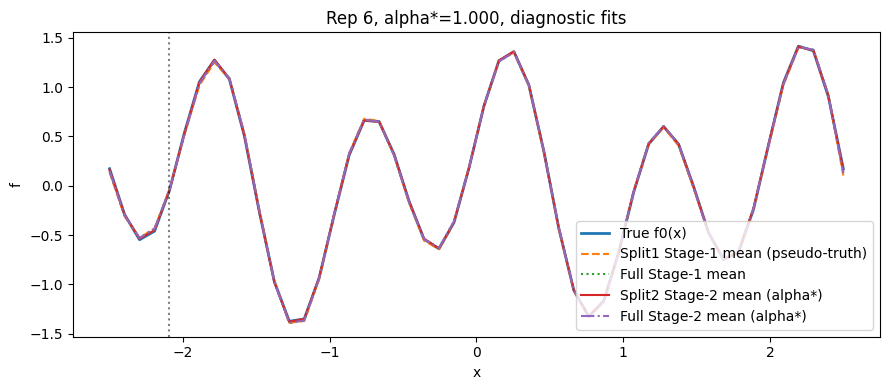

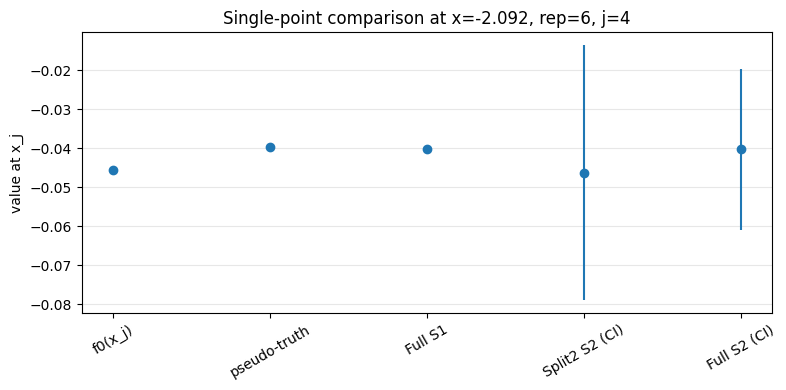

In [3]:
# 单 rep・单点 debug：calibration vs double-check 对比

import os, math, time
from dataclasses import dataclass
from contextlib import ExitStack

import torch
import gpytorch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ----------------- 配置 & 路径 -----------------

@dataclass
class CFG:
    # data
    n_train: int = 500
    n_test: int = 50
    train_low: float = -2.5
    train_high: float = 2.5
    test_low: float = -2.5
    test_high: float = 2.5

    # model / training
    use_fp64: bool = True
    use_ciq: bool = False
    inducing_points: int = 50
    stage1_epochs: int = 2000
    stage2_epochs: int = 800
    batch_size: int = 500
    lr_adam_stage1: float = 2e-2
    lr_adam_stage2: float = 2e-2
    jitter: float = 1e-2
    seed: int = 13           # base seed; per rep: seed + rep_id

    # early stopping for Stage-1
    early_stop_patience: int = 60
    early_stop_min_delta: float = 1e-4

    # experiment
    ci_level: float = 0.95

    # logging
    log_epoch: bool = False
    log_every: int = 10


cfg = CFG()

# ---- 你要改的地方：本地结果路径 & 目标 rep / j ----
CALIB_DIR = r"C:\Users\yangy\two_split\results"
DOUBLECHECK_DIR = r"C:\Users\yangy\重现\新结果\doublecheck"

TARGET_REP = 6   # 例如 6、31、57 这些“坏的” rep
TARGET_J   = 4  # 在那个 rep 里挑一个 cov_calib≈1 但 cov_indicator=0 的 j

# ----------------- 工具函数 -----------------

def now():
    return time.strftime("%H:%M:%S")

def log(msg):
    print(f"[{now()}] {msg}", flush=True)

def gpu_mem_mb():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1e6
    return 0.0

def has_setting(name: str) -> bool:
    return hasattr(gpytorch.settings, name)

def ciq_context():
    stack = ExitStack()
    for name, val in [
        ("num_contour_quadrature", 15),
        ("ciq_samples", 16),
        ("ciq_max_iter", 30),
        ("ciq_forward_precision", 0.01),
        ("eval_cg_tolerance", 1e-4),
        ("max_root_decomposition_size", 64),
    ]:
        if has_setting(name):
            stack.enter_context(getattr(gpytorch.settings, name)(val))
    stack.enter_context(gpytorch.settings.fast_pred_var(True))
    return stack

def clone_state_dict(sd):
    out = {}
    for k, v in sd.items():
        out[k] = v.detach().clone() if torch.is_tensor(v) else v
    return out

# 真 f0
def f0(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(2 * math.pi * x) + 0.5 * torch.cos(3 * x)

# 1D LHS-like
def make_stratified_points_1d(n, low, high, generator, device, dtype):
    i = torch.arange(n, device=device, dtype=dtype)
    u = (i + torch.rand(n, generator=generator, device=device, dtype=dtype)) / n
    x = low + (high - low) * u
    perm = torch.randperm(n, generator=generator, device=device)
    return x[perm].unsqueeze(-1)

# ----------------- 模型 & 训练 -----------------

class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points_std: torch.Tensor):
        M = inducing_points_std.size(0)
        q_dist = gpytorch.variational.CholeskyVariationalDistribution(M)
        q_strat = gpytorch.variational.VariationalStrategy(
            self, inducing_points_std, q_dist, learn_inducing_locations=False
        )
        super().__init__(q_strat)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x_std):
        mean_x = self.mean_module(x_std)
        covar_x = self.covar_module(x_std)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def freeze_all_params(model, likelihood):
    for p in model.parameters():
        p.requires_grad_(False)
    for p in likelihood.parameters():
        p.requires_grad_(False)


def pick_covariance_params_svgp(model):
    trainables, names = [], []
    vdist_mod = None
    vs = getattr(model, "variational_strategy", None)
    if vs is not None:
        if hasattr(vs, "_variational_distribution"):
            vdist_mod = getattr(vs, "_variational_distribution")
        else:
            cand = getattr(vs, "variational_distribution", None)
            if isinstance(cand, torch.nn.Module):
                vdist_mod = cand
    if isinstance(vdist_mod, torch.nn.Module):
        for n, p in vdist_mod.named_parameters(recurse=True):
            low = n.lower()
            if "mean" in low:
                p.requires_grad_(False)
            elif any(k in low for k in ["chol", "std", "var", "covar", "factor"]):
                p.requires_grad_(True)
                trainables.append(p)
                names.append(f"vdist.{n}")
            else:
                p.requires_grad_(False)
    if not trainables:
        allow = (
            "chol_variational_covar", "variational_distribution.chol_covar",
            "variational_distribution._cholesky_factor", "_variational_distribution.chol_covar",
            "raw_covar", "chol_factor", "covar_factor", "variational_stddev", "raw_var",
            "qchol", "q_scale_tril"
        )
        for n, p in model.named_parameters():
            low = n.lower()
            if "variational_strategy" in low and any(k in low for k in allow) and "mean" not in low:
                p.requires_grad_(True)
                trainables.append(p)
                names.append(n)
    return trainables, names


def stage1_train(model, likelihood, x_train_std, y_train, lr, epochs, jitter,
                 batch_size, early_stop_patience, early_stop_min_delta,
                 log_epoch=False, log_every=10):
    N = x_train_std.size(0)
    mll = gpytorch.mlls.VariationalELBO(
        likelihood, model, num_data=N, beta=1.0
    )

    likelihood.noise_covar.raw_noise.requires_grad_(False)
    opt = torch.optim.Adam([
        {"params": model.variational_parameters()},
        {"params": model.hyperparameters()},
        {"params": likelihood.parameters()},
    ], lr=lr)

    loader = DataLoader(
        TensorDataset(x_train_std, y_train),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )

    model.train()
    likelihood.train()
    neg_elbo_hist = []
    best_loss = float("inf")
    best_epoch = 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd = clone_state_dict(likelihood.state_dict())
    patience = 0

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1:
                    loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                total += float(loss.item())
                n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)

            if best_loss - avg_loss > early_stop_min_delta:
                best_loss = avg_loss
                best_epoch = ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd = clone_state_dict(likelihood.state_dict())
                patience = 0
            else:
                patience += 1

            if log_epoch and (ep % log_every == 0 or ep == 1 or ep == epochs):
                log(f"[S1] epoch {ep:04d}/{epochs} | -ELBO={avg_loss:.6f} "
                    f"(best {best_loss:.6f}@{best_epoch})")

            if patience >= early_stop_patience:
                break

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval()
    likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss


def stage2_train_cov_only(model, likelihood, x_train_std, y_train, beta, lr,
                          epochs, jitter, batch_size):
    N = x_train_std.size(0)
    freeze_all_params(model, likelihood)
    cov_params, cov_names = pick_covariance_params_svgp(model)
    assert cov_params, "No covariance params found to train in Stage-2."

    mll = gpytorch.mlls.VariationalELBO(
        likelihood, model, num_data=N, beta=beta
    )
    opt = torch.optim.Adam(cov_params, lr=lr)

    loader = DataLoader(
        TensorDataset(x_train_std, y_train),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )

    model.train()
    likelihood.train()
    neg_elbo_hist = []
    best_loss = float("inf")
    best_epoch = 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd = clone_state_dict(likelihood.state_dict())

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1:
                    loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(cov_params, 5.0)
                opt.step()
                total += float(loss.item())
                n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)
            if avg_loss < best_loss:
                best_loss = avg_loss
                best_epoch = ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd = clone_state_dict(likelihood.state_dict())

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval()
    likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss, cov_names

# ----------------- 主调试流程 -----------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64 if cfg.use_fp64 else torch.float32)

log(f"Device: {device}, dtype: {torch.get_default_dtype()}")

# 1) 从 doublecheck 里读这个 rep / j 的记录
dc_path = os.path.join(DOUBLECHECK_DIR, f"rep_{TARGET_REP:03d}_doublecheck.csv")
dc_df = pd.read_csv(dc_path)
row = dc_df.iloc[TARGET_J]

x_j = float(row["x"])
alpha_star = float(row["alpha_star"])
cov_indicator = float(row["cov_indicator"])
cov_calib = float(row["cov_at_alpha_star_calib"])

log(f"[Doublecheck CSV] rep={TARGET_REP}, j={TARGET_J}, x={x_j:.6f}, "
    f"alpha_star={alpha_star:.4f}, cov_ind={cov_indicator}, cov_calib={cov_calib:.3f}")

# 2) 重建这一 rep 的数据、split、Stage-1 模型

seed_r = cfg.seed + TARGET_REP
torch.manual_seed(seed_r)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed_r)

gen = torch.Generator(device=device).manual_seed(seed_r)

# 训练 + 测试
x_train_raw = make_stratified_points_1d(
    n=cfg.n_train, low=cfg.train_low, high=cfg.train_high,
    generator=gen, device=device, dtype=torch.get_default_dtype()
)
x_test_raw = torch.linspace(
    cfg.test_low, cfg.test_high, cfg.n_test,
    device=device, dtype=torch.get_default_dtype()
).unsqueeze(1)

y_train_full = f0(x_train_raw).squeeze(-1)
y_test_true = f0(x_test_raw).squeeze(-1)

# 对称线性标准化
mid = torch.tensor(
    [(cfg.train_low + cfg.train_high) / 2.0],
    device=device, dtype=torch.get_default_dtype()
)
half = torch.tensor(
    [(cfg.train_high - cfg.train_low) / 2.0],
    device=device, dtype=torch.get_default_dtype()
).clamp_min(1e-12)

def to_std(x_raw):
    return (x_raw - mid) / half

x_train_std_full = to_std(x_train_raw)
x_test_std = to_std(x_test_raw)

# inducing points
Z_raw = torch.linspace(
    cfg.train_low, cfg.train_high, cfg.inducing_points,
    device=device, dtype=torch.get_default_dtype()
).unsqueeze(1)
Z_std = to_std(Z_raw)

log(f"Training set reconstructed: n_train={x_train_raw.shape[0]}")
log(f"Test grid first/last x: {float(x_test_raw[0]):.3f}, {float(x_test_raw[-1]):.3f}")

# 两半 split
n_train = cfg.n_train
perm = torch.randperm(n_train, device=device)
half_n = n_train // 2
split1_idx = perm[:half_n]
split2_idx = perm[half_n:]

x_s1_std = x_train_std_full[split1_idx]
y_s1 = y_train_full[split1_idx]
x_s2_std = x_train_std_full[split2_idx]
y_s2 = y_train_full[split2_idx]

# ---- Split1 Stage-1 -> pseudo-truth ----
model_s1 = SVGPModel(Z_std.clone().contiguous()).to(device=device)
lik_s1 = gpytorch.likelihoods.GaussianLikelihood().to(device=device)
with torch.no_grad():
    model_s1.covar_module.base_kernel.lengthscale.fill_(1.0)
    model_s1.covar_module.outputscale.fill_(1.0)
    lik_s1.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)
lik_s1.noise_covar.raw_noise.requires_grad_(False)

log("[Split1] Stage-1 training...")
with (ciq_context() if cfg.use_ciq else ExitStack()):
    s1_hist_split1, best_ep_s1_1, best_loss_s1_1 = stage1_train(
        model_s1, lik_s1, x_s1_std, y_s1,
        lr=cfg.lr_adam_stage1, epochs=cfg.stage1_epochs, jitter=cfg.jitter,
        batch_size=cfg.batch_size,
        early_stop_patience=cfg.early_stop_patience,
        early_stop_min_delta=cfg.early_stop_min_delta,
        log_epoch=False, log_every=cfg.log_every
    )

with torch.no_grad():
    mu_truth = model_s1(x_test_std).mean

log(f"[Split1] best -ELBO={best_loss_s1_1:.6f} at epoch {best_ep_s1_1}")

# ---- Split2 Stage-1 base ----
model_s2 = SVGPModel(Z_std.clone().contiguous()).to(device=device)
lik_s2 = gpytorch.likelihoods.GaussianLikelihood().to(device=device)
with torch.no_grad():
    model_s2.covar_module.base_kernel.lengthscale.fill_(1.0)
    model_s2.covar_module.outputscale.fill_(1.0)
    lik_s2.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)
lik_s2.noise_covar.raw_noise.requires_grad_(False)

log("[Split2] Stage-1 training...")
with (ciq_context() if cfg.use_ciq else ExitStack()):
    s1_hist_split2, best_ep_s1_2, best_loss_s1_2 = stage1_train(
        model_s2, lik_s2, x_s2_std, y_s2,
        lr=cfg.lr_adam_stage1, epochs=cfg.stage1_epochs, jitter=cfg.jitter,
        batch_size=cfg.batch_size,
        early_stop_patience=cfg.early_stop_patience,
        early_stop_min_delta=cfg.early_stop_min_delta,
        log_epoch=False, log_every=cfg.log_every
    )

base_model_s2_sd = clone_state_dict(model_s2.state_dict())
base_lik_s2_sd = clone_state_dict(lik_s2.state_dict())
with torch.no_grad():
    mu_split2_s1 = model_s2(x_test_std).mean

log(f"[Split2] best -ELBO={best_loss_s1_2:.6f} at epoch {best_ep_s1_2}")

# ---- Full Stage-1 ----
model_full = SVGPModel(Z_std.clone().contiguous()).to(device=device)
lik_full = gpytorch.likelihoods.GaussianLikelihood().to(device=device)
with torch.no_grad():
    model_full.covar_module.base_kernel.lengthscale.fill_(1.0)
    model_full.covar_module.outputscale.fill_(1.0)
    lik_full.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)
lik_full.noise_covar.raw_noise.requires_grad_(False)

log("[Full] Stage-1 training...")
with (ciq_context() if cfg.use_ciq else ExitStack()):
    s1_hist_full, best_ep_s1_f, best_loss_s1_f = stage1_train(
        model_full, lik_full, x_train_std_full, y_train_full,
        lr=cfg.lr_adam_stage1, epochs=cfg.stage1_epochs, jitter=cfg.jitter,
        batch_size=cfg.batch_size,
        early_stop_patience=cfg.early_stop_patience,
        early_stop_min_delta=cfg.early_stop_min_delta,
        log_epoch=False, log_every=cfg.log_every
    )

with torch.no_grad():
    mu_full_s1 = model_full(x_test_std).mean

log(f"[Full] best -ELBO={best_loss_s1_f:.6f} at epoch {best_ep_s1_f}")

# 3) Stage-2 in calibration world: split2 + alpha_star, 全数据一次（代表性）
beta_star = 1.0 / alpha_star
log(f"[Split2] Stage-2 with alpha*={alpha_star:.4f} (beta={beta_star:.4f})")

model_s2.load_state_dict(base_model_s2_sd)
lik_s2.load_state_dict(base_lik_s2_sd)
with (ciq_context() if cfg.use_ciq else ExitStack()):
    s2_hist_split2, best_ep_s2_2, best_loss_s2_2, _ = stage2_train_cov_only(
        model_s2, lik_s2, x_s2_std, y_s2,
        beta=beta_star, lr=cfg.lr_adam_stage2, epochs=cfg.stage2_epochs,
        jitter=cfg.jitter, batch_size=cfg.batch_size
    )

with torch.no_grad():
    pred_split2_s2 = model_s2(x_test_std)
    mu_split2_s2 = pred_split2_s2.mean
    std_split2_s2 = pred_split2_s2.variance.sqrt().clamp_min(1e-12)

log(f"[Split2] Stage-2 best -ELBO={best_loss_s2_2:.6f} at epoch {best_ep_s2_2}")

# 4) Stage-2 in double-check world: full data + alpha_star
log(f"[Full] Stage-2 with alpha*={alpha_star:.4f} (beta={beta_star:.4f})")

model_full_s2 = SVGPModel(Z_std.clone().contiguous()).to(device=device)
lik_full_s2 = gpytorch.likelihoods.GaussianLikelihood().to(device=device)
with torch.no_grad():
    model_full_s2.covar_module.base_kernel.lengthscale.fill_(1.0)
    model_full_s2.covar_module.outputscale.fill_(1.0)
    lik_full_s2.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)
lik_full_s2.noise_covar.raw_noise.requires_grad_(False)

# 先加载 full Stage-1 checkpoint
model_full_s2.load_state_dict(clone_state_dict(model_full.state_dict()))
lik_full_s2.load_state_dict(clone_state_dict(lik_full.state_dict()))

with (ciq_context() if cfg.use_ciq else ExitStack()):
    s2_hist_full, best_ep_s2_f, best_loss_s2_f, _ = stage2_train_cov_only(
        model_full_s2, lik_full_s2, x_train_std_full, y_train_full,
        beta=beta_star, lr=cfg.lr_adam_stage2, epochs=cfg.stage2_epochs,
        jitter=cfg.jitter, batch_size=cfg.batch_size
    )

with torch.no_grad():
    pred_full_s2 = model_full_s2(x_test_std)
    mu_full_s2 = pred_full_s2.mean
    std_full_s2 = pred_full_s2.variance.sqrt().clamp_min(1e-12)

log(f"[Full] Stage-2 best -ELBO={best_loss_s2_f:.6f} at epoch {best_ep_s2_f}")

# 5) 单点 j 的详细数值 & 覆盖情况

idx_j = TARGET_J
idx_tensor = torch.tensor([idx_j], device=device, dtype=torch.long)

z_ci = 1.96  # 95% CI

f0_j = y_test_true[idx_tensor][0].item()
mu_truth_j = mu_truth[idx_tensor][0].item()
mu_full_s1_j = mu_full_s1[idx_tensor][0].item()
mu_split2_s2_j = mu_split2_s2[idx_tensor][0].item()
std_split2_s2_j = std_split2_s2[idx_tensor][0].item()
mu_full_s2_j = mu_full_s2[idx_tensor][0].item()
std_full_s2_j = std_full_s2[idx_tensor][0].item()

ci_split2 = (mu_split2_s2_j - z_ci * std_split2_s2_j,
             mu_split2_s2_j + z_ci * std_split2_s2_j)
ci_full   = (mu_full_s2_j - z_ci * std_full_s2_j,
             mu_full_s2_j + z_ci * std_full_s2_j)

def in_ci(val, ci):
    return (val >= ci[0]) and (val <= ci[1])

log("\n=========== Single-point diagnostics ===========")
log(f"rep={TARGET_REP}, j={TARGET_J}, x_j={x_j:.6f}, alpha*={alpha_star:.4f}")
log(f"  f0(x_j)            = {f0_j:.6f}")
log(f"  pseudo-truth mu_s1_split1(x_j) = {mu_truth_j:.6f}")
log(f"  full Stage-1 mu_full(x_j)      = {mu_full_s1_j:.6f}")

log("\n[Calibration world: split2 Stage-2 (no bootstrap, full split2 data)]")
log(f"  mu_split2_s2(x_j)   = {mu_split2_s2_j:.6f}")
log(f"  std_split2_s2(x_j)  = {std_split2_s2_j:.6f}")
log(f"  CI_split2           = [{ci_split2[0]:.6f}, {ci_split2[1]:.6f}]")
log(f"  CI_split2 covers pseudo-truth? {in_ci(mu_truth_j, ci_split2)}")
log(f"  CI_split2 covers f0?           {in_ci(f0_j, ci_split2)}")

log("\n[Double-check world: full Stage-2]")
log(f"  mu_full_s2(x_j)     = {mu_full_s2_j:.6f}")
log(f"  std_full_s2(x_j)    = {std_full_s2_j:.6f}")
log(f"  CI_full             = [{ci_full[0]:.6f}, {ci_full[1]:.6f}]")
log(f"  CI_full covers pseudo-truth?   {in_ci(mu_truth_j, ci_full)}")
log(f"  CI_full covers f0?             {in_ci(f0_j, ci_full)}")

# 6) 画图：整个区间的 fit 对比 & 单点误差条

x_axis = x_test_raw.squeeze(-1).cpu().numpy()
f0_np = y_test_true.cpu().numpy()
mu_truth_np = mu_truth.cpu().numpy()
mu_full_s1_np = mu_full_s1.cpu().numpy()
mu_split2_s2_np = mu_split2_s2.cpu().numpy()
mu_full_s2_np = mu_full_s2.cpu().numpy()

plt.figure(figsize=(9,4))
plt.plot(x_axis, f0_np, label="True f0(x)", linewidth=2)
plt.plot(x_axis, mu_truth_np, "--", label="Split1 Stage-1 mean (pseudo-truth)")
plt.plot(x_axis, mu_full_s1_np, ":", label="Full Stage-1 mean")
plt.plot(x_axis, mu_split2_s2_np, "-", label="Split2 Stage-2 mean (alpha*)")
plt.plot(x_axis, mu_full_s2_np, "-.", label="Full Stage-2 mean (alpha*)")
plt.axvline(x_j, color="k", linestyle=":", alpha=0.5)
plt.title(f"Rep {TARGET_REP}, alpha*={alpha_star:.3f}, diagnostic fits")
plt.xlabel("x")
plt.ylabel("f")
plt.legend()
plt.tight_layout()
plt.show()

# 单点误差条图
labels = ["f0(x_j)", "pseudo-truth", "Full S1", "Split2 S2 (CI)", "Full S2 (CI)"]
x_pos = np.arange(len(labels))
y_vals = [
    f0_j,
    mu_truth_j,
    mu_full_s1_j,
    mu_split2_s2_j,
    mu_full_s2_j,
]
y_err = [
    0.0,
    0.0,
    0.0,
    z_ci * std_split2_s2_j,
    z_ci * std_full_s2_j,
]

plt.figure(figsize=(8,4))
plt.errorbar(x_pos, y_vals, yerr=y_err, fmt="o")
plt.xticks(x_pos, labels, rotation=30)
plt.ylabel("value at x_j")
plt.title(f"Single-point comparison at x={x_j:.3f}, rep={TARGET_REP}, j={TARGET_J}")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


[22:03:15] Total rows: 5000
[22:03:15] Overall mean double-check coverage: 0.9404
[22:03:15] Overall mean calib coverage at alpha*: 0.995846
[22:03:15] Bad points (calib≈1, doublecheck=0): 256
[22:03:15] Top reps with many bad points:
[22:03:15] rep
6     16
57    16
31    16
10    13
68    11
26    10
15     9
92     9
80     9
45     9
Name: count, dtype: int64
[22:03:16] Device: cuda, dtype: torch.float64
[22:03:16] Using z_ci=1.9600 for ci_level=0.95
[22:03:16] Re-running full-data two-stage for reps: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
[22:03:16] ======================================================================
[22:03:16] Processing rep 1
[22:03:16] Bad points in rep 1: 8, unique alpha*=[1.]
[22:03:27] [rep 1] Full Stage-1 best -ELBO=-1.697446 @ep=730
[22:03:27] [rep 1] alpha*=1.0000, num bad points=8
[22:03:39]     Stage-2 done (beta=1.0000), best -ELBO=-1.704045 @ep=568
[22:03:39] ================================================================

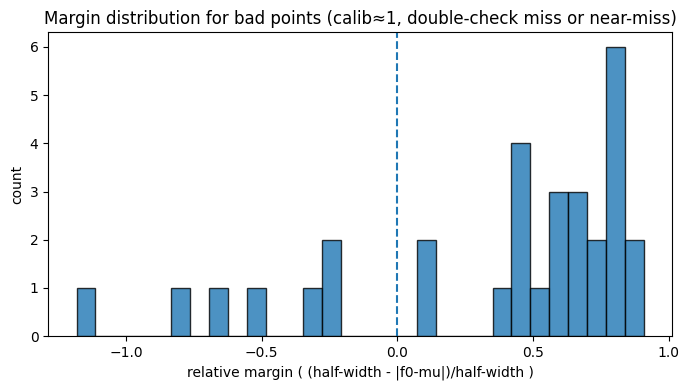

In [2]:
# ==== 用户需要修改的路径 ====
CALIB_DIR = r"C:\Users\yangy\two_split\results"                 # calibration 结果根目录
DOUBLECHECK_DIR = r"C:\Users\yangy\重现\新结果\doublecheck"      # doublecheck CSV 根目录
MAX_REPS = 5   # 先只分析坏点最多的前 N 个 rep；设成 None 就分析所有坏点 rep

# ==== 下面代码不用改，直接跑即可 ====

import os, glob, math, time
from dataclasses import dataclass
from contextlib import ExitStack

import numpy as np
import pandas as pd
import torch
import gpytorch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ---------- logging ----------
def now(): return time.strftime("%H:%M:%S")
def log(msg): print(f"[{now()}] {msg}", flush=True)

# ---------- GP helpers（从你的 py 里复制的精简版） ----------

def f0(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(2 * math.pi * x) + 0.5 * torch.cos(3 * x)

def make_stratified_points_1d(n, low, high, generator, device, dtype):
    i = torch.arange(n, device=device, dtype=dtype)
    u = (i + torch.rand(n, generator=generator, device=device, dtype=dtype)) / n
    x = low + (high - low) * u
    perm = torch.randperm(n, generator=generator, device=device)
    return x[perm].unsqueeze(-1)

def clone_state_dict(sd):
    out = {}
    for k, v in sd.items():
        out[k] = v.detach().clone() if torch.is_tensor(v) else v
    return out

@dataclass
class CFG:
    n_train: int = 500
    n_test: int = 50
    train_low: float = -2.5
    train_high: float = 2.5
    test_low: float = -2.5
    test_high: float = 2.5

    use_fp64: bool = True
    use_ciq: bool = False
    inducing_points: int = 50
    stage1_epochs: int = 2000
    stage2_epochs: int = 800
    batch_size: int = 500
    lr_adam_stage1: float = 2e-2
    lr_adam_stage2: float = 2e-2
    jitter: float = 1e-2
    seed: int = 13

    early_stop_patience: int = 60
    early_stop_min_delta: float = 1e-4
    ci_level: float = 0.95
    log_epoch: bool = False
    log_every: int = 10

cfg = CFG()

class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points_std: torch.Tensor):
        M = inducing_points_std.size(0)
        q_dist = gpytorch.variational.CholeskyVariationalDistribution(M)
        q_strat = gpytorch.variational.VariationalStrategy(
            self, inducing_points_std, q_dist, learn_inducing_locations=False
        )
        super().__init__(q_strat)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )
    def forward(self, x_std):
        mean_x = self.mean_module(x_std)
        covar_x = self.covar_module(x_std)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def freeze_all_params(model, likelihood):
    for p in model.parameters():      p.requires_grad_(False)
    for p in likelihood.parameters(): p.requires_grad_(False)

def pick_covariance_params_svgp(model):
    trainables, names = [], []
    vdist_mod = None
    vs = getattr(model, "variational_strategy", None)
    if vs is not None:
        if hasattr(vs, "_variational_distribution"):
            vdist_mod = getattr(vs, "_variational_distribution")
        else:
            cand = getattr(vs, "variational_distribution", None)
            if isinstance(cand, torch.nn.Module):
                vdist_mod = cand
    if isinstance(vdist_mod, torch.nn.Module):
        for n, p in vdist_mod.named_parameters(recurse=True):
            low = n.lower()
            if "mean" in low:
                p.requires_grad_(False)
            elif any(k in low for k in ["chol", "std", "var", "covar", "factor"]):
                p.requires_grad_(True); trainables.append(p); names.append(f"vdist.{n}")
            else:
                p.requires_grad_(False)
    if not trainables:
        allow = (
            "chol_variational_covar", "variational_distribution.chol_covar",
            "variational_distribution._cholesky_factor", "_variational_distribution.chol_covar",
            "raw_covar", "chol_factor", "covar_factor", "variational_stddev", "raw_var",
            "qchol", "q_scale_tril"
        )
        for n, p in model.named_parameters():
            low = n.lower()
            if "variational_strategy" in low and any(k in low for k in allow) and "mean" not in low:
                p.requires_grad_(True); trainables.append(p); names.append(n)
    return trainables, names

def stage1_train(model, likelihood, x_train_std, y_train, lr, epochs, jitter,
                 batch_size, early_stop_patience, early_stop_min_delta,
                 log_epoch=False, log_every=10):
    N = x_train_std.size(0)
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=1.0)
    likelihood.noise_covar.raw_noise.requires_grad_(False)
    opt = torch.optim.Adam([
        {"params": model.variational_parameters()},
        {"params": model.hyperparameters()},
        {"params": likelihood.parameters()},
    ], lr=lr)

    loader = DataLoader(TensorDataset(x_train_std, y_train),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model.train(); likelihood.train()
    neg_elbo_hist = []
    best_loss = float("inf"); best_epoch = 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd = clone_state_dict(likelihood.state_dict())
    patience = 0

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs+1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1: loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)

            if best_loss - avg_loss > early_stop_min_delta:
                best_loss = avg_loss; best_epoch = ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd = clone_state_dict(likelihood.state_dict())
                patience = 0
            else:
                patience += 1

            if log_epoch and (ep % log_every == 0 or ep == 1 or ep == epochs):
                log(f"[S1] ep {ep:04d}/{epochs} | -ELBO={avg_loss:.6f} (best {best_loss:.6f}@{best_epoch})")

            if patience >= early_stop_patience:
                break

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss

def stage2_train_cov_only(model, likelihood, x_train_std, y_train, beta, lr,
                          epochs, jitter, batch_size):
    N = x_train_std.size(0)
    freeze_all_params(model, likelihood)
    cov_params, cov_names = pick_covariance_params_svgp(model)
    assert cov_params, "No covariance params found to train in Stage-2."
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=beta)
    opt = torch.optim.Adam(cov_params, lr=lr)

    loader = DataLoader(TensorDataset(x_train_std, y_train),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model.train(); likelihood.train()
    neg_elbo_hist = []
    best_loss = float("inf"); best_epoch = 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd = clone_state_dict(likelihood.state_dict())

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs+1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1: loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(cov_params, 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)
            if avg_loss < best_loss:
                best_loss = avg_loss; best_epoch = ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd = clone_state_dict(likelihood.state_dict())

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss, cov_names

# ---------- 1. 读 doublecheck -> all_df, 找 bad_df ----------

dc_files = sorted(glob.glob(os.path.join(DOUBLECHECK_DIR, "rep_*_doublecheck.csv")))
assert dc_files, f"No doublecheck CSVs found in {DOUBLECHECK_DIR}"

rows = []
for path in dc_files:
    fname = os.path.basename(path)
    rep_str = fname.split("_")[1]  # rep_006_doublecheck.csv -> '006'
    rep_id = int(rep_str)
    df = pd.read_csv(path)
    J = df.shape[0]
    for j in range(J):
        rows.append({
            "rep": rep_id,
            "j": j,
            "x": df.loc[j, "x"],
            "alpha_star": df.loc[j, "alpha_star"],
            "cov_ind": df.loc[j, "cov_indicator"],
            "cov_calib": df.loc[j, "cov_at_alpha_star_calib"],
        })

all_df = pd.DataFrame(rows)
log(f"Total rows: {len(all_df)}")

overall_cov = all_df["cov_ind"].mean()
overall_calib_cov = all_df["cov_calib"].mean()
log(f"Overall mean double-check coverage: {overall_cov:.4f}")
log(f"Overall mean calib coverage at alpha*: {overall_calib_cov:.6f}")

bad_df = all_df[(all_df["cov_calib"] > 0.99) & (all_df["cov_ind"] == 0.0)].copy()
log(f"Bad points (calib≈1, doublecheck=0): {len(bad_df)}")
log("Top reps with many bad points:")
log(str(bad_df["rep"].value_counts().head(10)))

# ---------- 2. 对 bad_df 的 reps，重跑 full-data two-stage，算 margin ----------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64 if cfg.use_fp64 else torch.float32)
log(f"Device: {device}, dtype: {torch.get_default_dtype()}")

# 正态分位数（95% CI）
norm = torch.distributions.Normal(
    torch.tensor(0.0, device=device, dtype=torch.get_default_dtype()),
    torch.tensor(1.0, device=device, dtype=torch.get_default_dtype())
)
z_ci = float(norm.icdf(torch.tensor([(1.0 + cfg.ci_level) / 2.0], device=device))[0].item())
log(f"Using z_ci={z_ci:.4f} for ci_level={cfg.ci_level}")

rep_list = sorted(bad_df["rep"].unique())
if MAX_REPS is not None:
    rep_list = rep_list[:MAX_REPS]
log(f"Re-running full-data two-stage for reps: {rep_list}")

margin_records = []

for rep_id in rep_list:
    log("="*70)
    log(f"Processing rep {rep_id}")
    # ---- 2.1 读 calibration CSV, 重算 alpha_star(r,j) ----
    rep_dir = os.path.join(CALIB_DIR, f"rep_{rep_id}")
    pattern = os.path.join(rep_dir, "pointwise_coverage_rep*_A*_B*.csv")
    calib_files = glob.glob(pattern)
    assert len(calib_files) == 1, f"Expected 1 calib CSV in {rep_dir}, found {len(calib_files)}"
    calib_path = calib_files[0]
    calib_df = pd.read_csv(calib_path)

    assert calib_df.columns[0].startswith("x")
    x_axis = calib_df.iloc[:, 0].to_numpy()
    J = x_axis.shape[0]
    alpha_cols = [c for c in calib_df.columns if c.startswith("alpha_")]
    alpha_vals = np.array([float(c.split("_")[1]) for c in alpha_cols], dtype=float)
    coverage_mat = calib_df[alpha_cols].to_numpy()  # [J, A]

    # 重新算 alpha_star
    alpha_star_recalc = np.zeros(J, dtype=float)
    cov_at_alpha_star = np.zeros(J, dtype=float)
    for j in range(J):
        cov_row = coverage_mat[j, :]
        order_desc = np.argsort(alpha_vals)[::-1]
        alphas_desc = alpha_vals[order_desc]
        cov_desc = cov_row[order_desc]
        idx_ge = np.where(cov_desc >= cfg.ci_level)[0]
        if idx_ge.size > 0:
            chosen_desc_idx = idx_ge[0]
        else:
            chosen_desc_idx = int(np.argmax(cov_desc))
        best_idx = int(order_desc[chosen_desc_idx])
        alpha_star_recalc[j] = alpha_vals[best_idx]
        cov_at_alpha_star[j] = cov_row[best_idx]

    # sanity check：和 doublecheck 的 alpha_star 是否一致
    alpha_star_dc = all_df[all_df["rep"] == rep_id].sort_values("j")["alpha_star"].to_numpy()
    assert np.allclose(alpha_star_recalc, alpha_star_dc), "alpha_star mismatch between calib and doublecheck"

    # 当前 rep 的 bad points（只看这几个 j）
    bad_r = bad_df[bad_df["rep"] == rep_id].copy()
    bad_js = bad_r["j"].to_numpy().astype(int)
    bad_alpha_vals = np.unique(bad_r["alpha_star"].to_numpy())
    log(f"Bad points in rep {rep_id}: {len(bad_r)}, unique alpha*={bad_alpha_vals}")

        # ---- 2.2 构造 full-data 训练集 & test grid ----
    seed_r = cfg.seed + int(rep_id)          # 保证是 Python int
    seed_r_int = int(seed_r)

    torch.manual_seed(seed_r_int)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_r_int)

    gen = torch.Generator(device=device).manual_seed(seed_r_int)

    x_train_raw = make_stratified_points_1d(
        n=cfg.n_train, low=cfg.train_low, high=cfg.train_high,
        generator=gen, device=device, dtype=torch.get_default_dtype()
    )

    y_train = f0(x_train_raw).squeeze(-1)

    x_test_raw = torch.tensor(x_axis, device=device,
                              dtype=torch.get_default_dtype()).unsqueeze(1)
    y_test_true = f0(x_test_raw).squeeze(-1)

    mid = torch.tensor([(cfg.train_low + cfg.train_high) / 2.0],
                       device=device, dtype=torch.get_default_dtype())
    half = torch.tensor([(cfg.train_high - cfg.train_low) / 2.0],
                        device=device, dtype=torch.get_default_dtype()).clamp_min(1e-12)

    def to_std(x_raw):
        return (x_raw - mid) / half

    x_train_std = to_std(x_train_raw)
    x_test_std = to_std(x_test_raw)

    Z_raw = torch.linspace(cfg.train_low, cfg.train_high, cfg.inducing_points,
                           device=device, dtype=torch.get_default_dtype()).unsqueeze(1)
    Z_std = to_std(Z_raw)

    # ---- 2.3 全数据 Stage-1 ----
    model = SVGPModel(Z_std.clone().contiguous()).to(device=device)
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device)
    with torch.no_grad():
        model.covar_module.base_kernel.lengthscale.fill_(1.0)
        model.covar_module.outputscale.fill_(1.0)
        likelihood.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)
    likelihood.noise_covar.raw_noise.requires_grad_(False)

    _, best_ep_s1, best_loss_s1 = stage1_train(
        model, likelihood, x_train_std, y_train,
        lr=cfg.lr_adam_stage1, epochs=cfg.stage1_epochs,
        jitter=cfg.jitter, batch_size=cfg.batch_size,
        early_stop_patience=cfg.early_stop_patience,
        early_stop_min_delta=cfg.early_stop_min_delta,
        log_epoch=False, log_every=cfg.log_every
    )
    log(f"[rep {rep_id}] Full Stage-1 best -ELBO={best_loss_s1:.6f} @ep={best_ep_s1}")

    s1_model_sd = clone_state_dict(model.state_dict())
    s1_lik_sd = clone_state_dict(likelihood.state_dict())

    # ---- 2.4 对 bad_alpha_vals 里的每个 alpha* 做 Stage-2 + margin  ----
    for alpha in bad_alpha_vals:
        beta = float(1.0 / alpha)
        js_this_alpha = bad_r[bad_r["alpha_star"] == alpha]["j"].to_numpy().astype(int)
        log(f"[rep {rep_id}] alpha*={alpha:.4f}, num bad points={len(js_this_alpha)}")

        # 重置为 Stage-1 状态
        model.load_state_dict(s1_model_sd)
        likelihood.load_state_dict(s1_lik_sd)
        model.eval(); likelihood.eval()

        _, best_ep_s2, best_loss_s2, _ = stage2_train_cov_only(
            model, likelihood, x_train_std, y_train,
            beta=beta, lr=cfg.lr_adam_stage2, epochs=cfg.stage2_epochs,
            jitter=cfg.jitter, batch_size=cfg.batch_size
        )
        log(f"    Stage-2 done (beta={beta:.4f}), best -ELBO={best_loss_s2:.6f} @ep={best_ep_s2}")

        with torch.no_grad():
            pred = model(x_test_std)
            mu = pred.mean
            std = pred.variance.sqrt().clamp_min(1e-12)
            half_width = z_ci * std
            lower = mu - half_width
            upper = mu + half_width

        for j in js_this_alpha:
            x_j = x_axis[j]
            f0_j = y_test_true[j].item()
            mu_j = mu[j].item()
            hw_j = half_width[j].item()
            lower_j = lower[j].item()
            upper_j = upper[j].item()

            margin = (hw_j - abs(f0_j - mu_j)) / hw_j   # >0: inside, <0: outside

            row_bad = bad_r[bad_r["j"] == j].iloc[0]
            margin_records.append({
                "rep": rep_id,
                "j": j,
                "x": x_j,
                "alpha_star": alpha,
                "cov_ind": row_bad["cov_ind"],
                "cov_calib": row_bad["cov_calib"],
                "mu": mu_j,
                "lower": lower_j,
                "upper": upper_j,
                "f0": f0_j,
                "margin": margin,
            })

# ---------- 3. 汇总 & 画直方图 ----------

margin_df = pd.DataFrame(margin_records)
log(f"\nCollected margins for {len(margin_df)} bad points across reps {rep_list}")

log("Margin stats (all bad points in these reps):")
log(str(margin_df["margin"].describe()))

plt.figure(figsize=(7,4))
plt.hist(margin_df["margin"], bins=30, edgecolor="black", alpha=0.8)
plt.axvline(0.0, linestyle="--")
plt.xlabel("relative margin ( (half-width - |f0-mu|)/half-width )")
plt.ylabel("count")
plt.title("Margin distribution for bad points (calib≈1, double-check miss or near-miss)")
plt.tight_layout()
plt.show()


[22:08:40] Total bad points (calib≈1 & doublecheck=0) in these reps: 31
[22:08:40] Severe misses with margin <= 0: 7
[22:08:40] First few severe-miss points (sorted by margin):


,rep,j,x,alpha_star,cov_calib,margin
17,4,6,-1.887755,1.0,1.0,-1.182501
19,4,10,-1.479592,1.0,1.0,-0.824203
18,4,9,-1.581633,1.0,1.0,-0.692936
23,4,49,2.500000,1.0,1.0,-0.536164
22,4,48,2.397959,1.0,1.0,-0.292247
20,4,13,-1.173469,1.0,1.0,-0.250111
21,4,47,2.295918,1.0,1.0,-0.241453


[22:08:40] x 的描述性统计（severe misses）:
count    7.000000
mean     0.153061
std      2.111037
min     -1.887755
25%     -1.530612
50%     -1.173469
75%      2.346939
max      2.500000
[22:08:40] Unique x positions for severe misses (sorted, up to 50 shown):
[-1.8877551  -1.58163265 -1.47959184 -1.17346939  2.29591837  2.39795918
  2.5       ]
[22:08:40] Worst 5 severe-miss points (these是最值得单点诊断的):
 rep  j         x  alpha_star  cov_calib    margin
   4  6 -1.887755         1.0        1.0 -1.182501
   4 10 -1.479592         1.0        1.0 -0.824203
   4  9 -1.581633         1.0        1.0 -0.692936
   4 49  2.500000         1.0        1.0 -0.536164
   4 48  2.397959         1.0        1.0 -0.292247


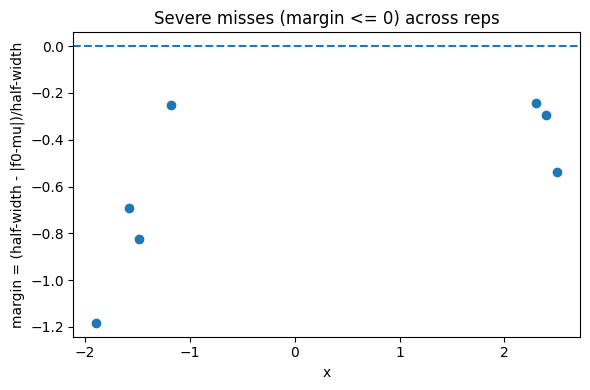

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 如果前面没定义 log，就简单定义一个
if "log" not in globals():
    import time
    def log(msg):
        print(f"[{time.strftime('%H:%M:%S')}] {msg}")

# 1. 只保留 margin <= 0 的“真 miss 点”
severe_df = margin_df[margin_df["margin"] <= 0].copy()

log(f"Total bad points (calib≈1 & doublecheck=0) in these reps: {len(margin_df)}")
log(f"Severe misses with margin <= 0: {len(severe_df)}")

if len(severe_df) == 0:
    log("👏 没有 margin <= 0 的点，说明之前的 miss 基本都是 near-miss。")
else:
    # 2. 看看这些点的基本信息
    cols_show = ["rep", "j", "x", "alpha_star", "cov_calib", "margin"]
    log("First few severe-miss points (sorted by margin):")
    display(
        severe_df[cols_show]
        .sort_values("margin")  # margin 越小，离区间越远
        .head(20)
    )

    # 3. 看看它们在 x 上的分布
    log("x 的描述性统计（severe misses）:")
    print(severe_df["x"].describe().to_string())

    unique_x = np.sort(severe_df["x"].unique())
    log(f"Unique x positions for severe misses (sorted, up to 50 shown):")
    print(unique_x[:50])
    if len(unique_x) > 50:
        log(f"... and {len(unique_x) - 50} more unique x values")

    # 4. 选出“最坏的几个点”，方便你拿去单点诊断 notebook 里 plug in
    worst_k = 5
    worst_points = (
        severe_df[cols_show]
        .sort_values("margin")  # margin 最负的排在前面
        .head(worst_k)
    )
    log(f"Worst {worst_k} severe-miss points (these是最值得单点诊断的):")
    print(worst_points.to_string(index=False))

    # 5. 画一张 scatter：margin vs x，看这些真 miss 集中在哪些位置
    plt.figure(figsize=(6,4))
    plt.scatter(severe_df["x"], severe_df["margin"])
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("x")
    plt.ylabel("margin = (half-width - |f0-mu|)/half-width")
    plt.title("Severe misses (margin <= 0) across reps")
    plt.tight_layout()
    plt.show()
